<a href="https://colab.research.google.com/github/saidanirafeek2011/Assignment-3-Data-Visualization.ipynb/blob/main/Copy_of_Assignment_3_Data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df #loaded dataset

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [ ]:
# Handling Missing Values
# Check for missing values in the dataset and identify columns with missing data.
nullvalue = df.isnull().sum()
nullvalue

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
print("\n Duplicate Rows: ", df.duplicated().sum())


 Duplicate Rows:  0


In [ ]:
#Fill missing values if its there
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols]
for cols in num_cols:
  df[cols] = df[cols].fillna(df[cols].mean())
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print('\nMissing vals after cleaning')
print(df.isnull().sum())


Missing vals after cleaning
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [ ]:
# Visualizations using Matplotlib/Pandas Plot:
# Line Chart
# Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and
# fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.
df['pickup'] = pd.to_datetime(df['pickup'])
df['hour'] = df['pickup'].dt.hour
print(df['pickup']) #verifying pickup is converted to date time format

0      2019-03-23 20:21:09
1      2019-03-04 16:11:55
2      2019-03-27 17:53:01
3      2019-03-10 01:23:59
4      2019-03-30 13:27:42
               ...        
6428   2019-03-31 09:51:53
6429   2019-03-31 17:38:00
6430   2019-03-23 22:55:18
6431   2019-03-04 10:09:25
6432   2019-03-13 19:31:22
Name: pickup, Length: 6433, dtype: datetime64[ns]


In [ ]:
print(df['hour'])

0       20
1       16
2       17
3        1
4       13
        ..
6428     9
6429    17
6430    22
6431    10
6432    19
Name: hour, Length: 6433, dtype: int32


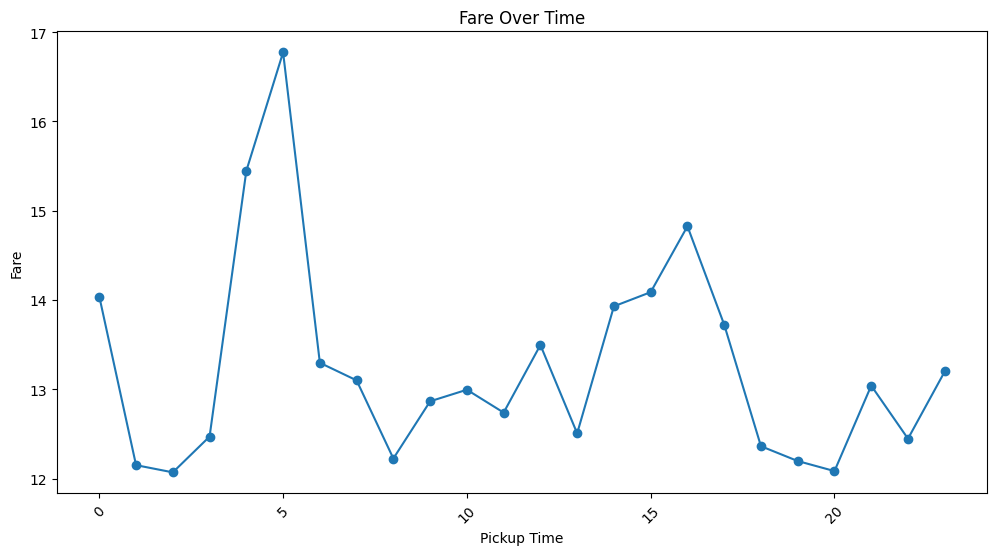

In [ ]:
fare_over_time=df.groupby('hour')['fare'].mean() #fare over time line plot
plt.figure(figsize=(12,6))
fare_over_time.plot(kind="line",marker = 'o')
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.xticks(rotation=45)
plt.show()

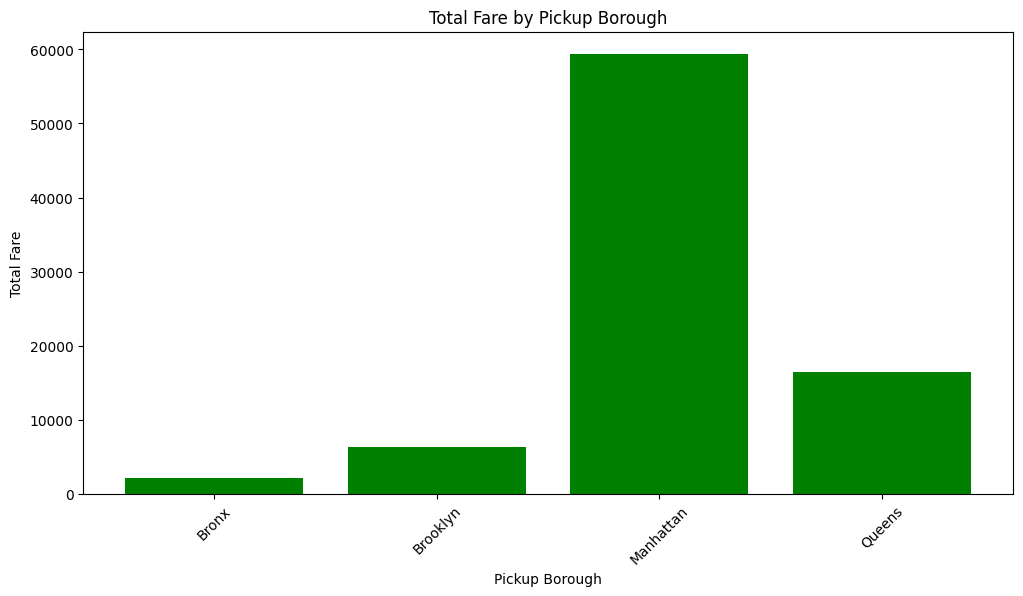

In [ ]:
# Bar Chart
# Create a bar chart to show the total fare for each pickup_borough. Group the data by
# pickup_borough and sum the fare for each group.
borough_fare = df.groupby('pickup_borough')['fare'].sum()
plt.figure(figsize=(12,6))
plt.bar(borough_fare.index, borough_fare.values,color='green')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.xticks(rotation=45)
plt.show()

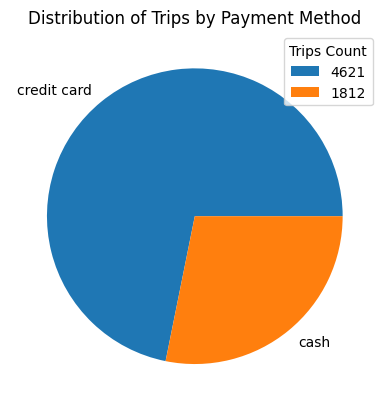

In [ ]:
# Pie Chart
# Plot a pie chart showing the distribution of trips based on the payment method (credit card,
# cash, etc.). Each slice should represent the count of trips for a specific payment method.
payment_counts = df['payment'].value_counts()
plt.pie(payment_counts,labels=payment_counts.index)
plt.legend(payment_counts.values, title="Trips Count")
plt.title('Distribution of Trips by Payment Method')
plt.ylabel('')
plt.show()

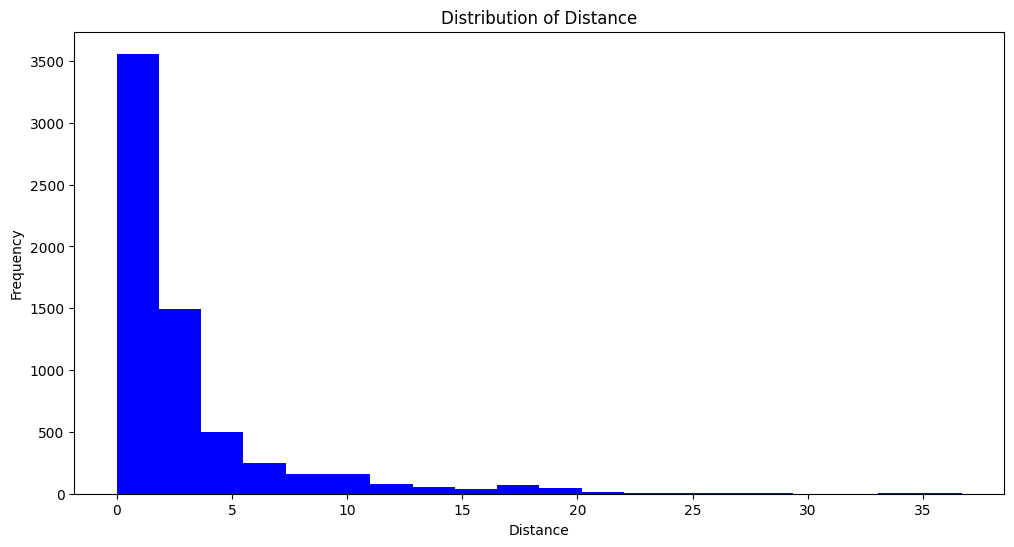

In [ ]:
# Histogram
# Create a histogram to visualize the distribution of distance. Customize the number of bins for
# better granularity and ensure the plot is easy to interpret.
plt.figure(figsize=(12,6))
plt.hist(df['distance'], bins=20, color='blue')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Distance')
plt.show()

Text(0.5, 1.0, 'Distribution of Tip Amounts by Pickup Borough')

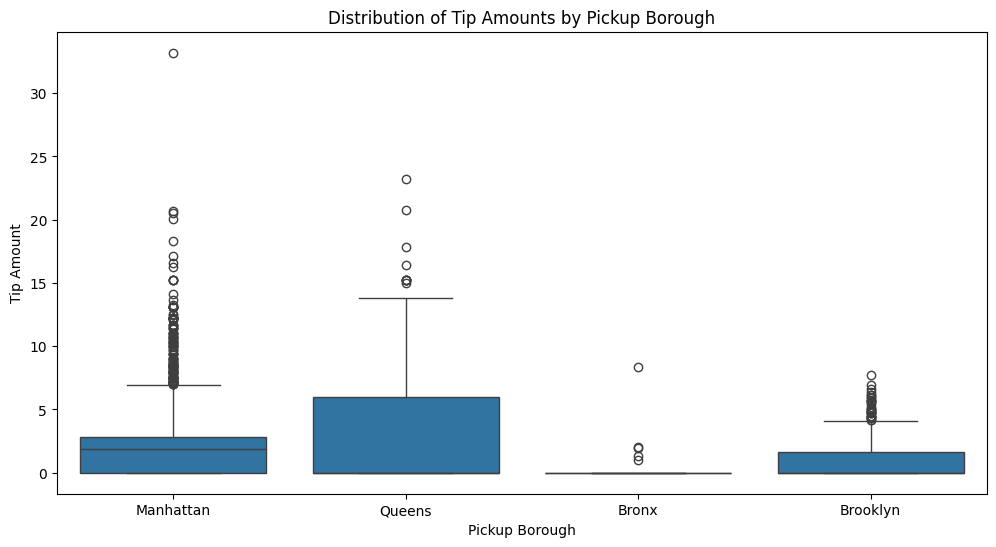

In [ ]:
# Box Plot
# Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use
# pickup_borough as the categorical axis and tip as the numeric axis.
plt.figure(figsize=(12,6))
sns.boxplot(x='pickup_borough', y='tip', data=df)
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Distribution of Tip Amounts by Pickup Borough')

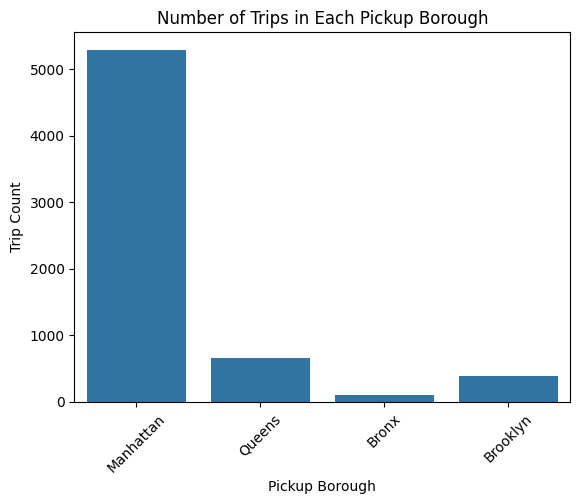

In [ ]:
# Visualizations using Seaborn:
# Count Plot
# Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should
# represent the boroughs, and the y-axis should show the count of trips.
sns.countplot(x='pickup_borough',data=df) #it directly takes the count of trips
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")
plt.title("Number of Trips in Each Pickup Borough")
plt.xticks(rotation=45)
plt.show()

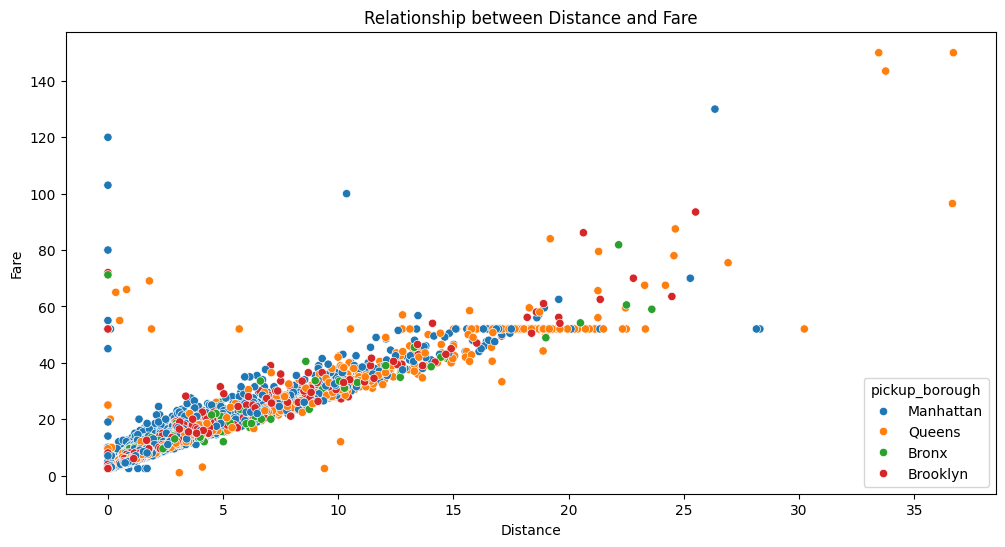

In [ ]:
# Scatter Plot
# Plot a scatterplot to show the relationship between distance and fare. Use distance on the
# x-axis and fare on the y-axis to visualize any correlation. Color the points based on the
# pickup_borough to differentiate the trips by their respective boroughs.
plt.figure(figsize=(12,6))
sns.scatterplot(x='distance', y='fare', data=df, hue='pickup_borough')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship between Distance and Fare')
plt.show()

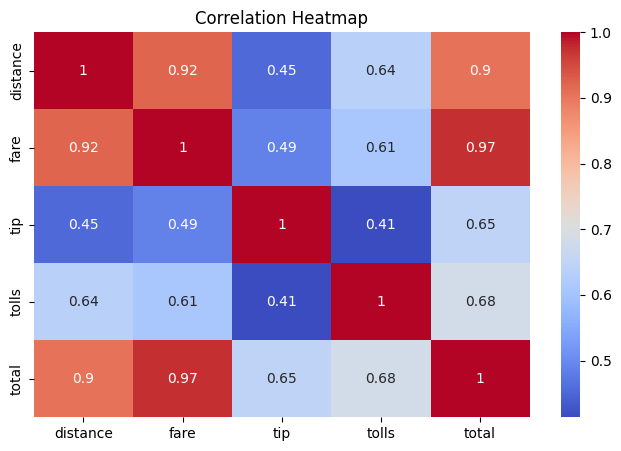

In [ ]:
# Heatmap
# Plot a heatmap to visualize the correlation between numerical variables such as distance, fare,
# tip, tolls, and total. Use a correlation matrix to highlight the relationships.
plt.figure(figsize = (8,5))
num_corel = df[['distance', 'fare', 'tip', 'tolls', 'total']]
sns.heatmap(num_corel.corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<Figure size 900x900 with 0 Axes>

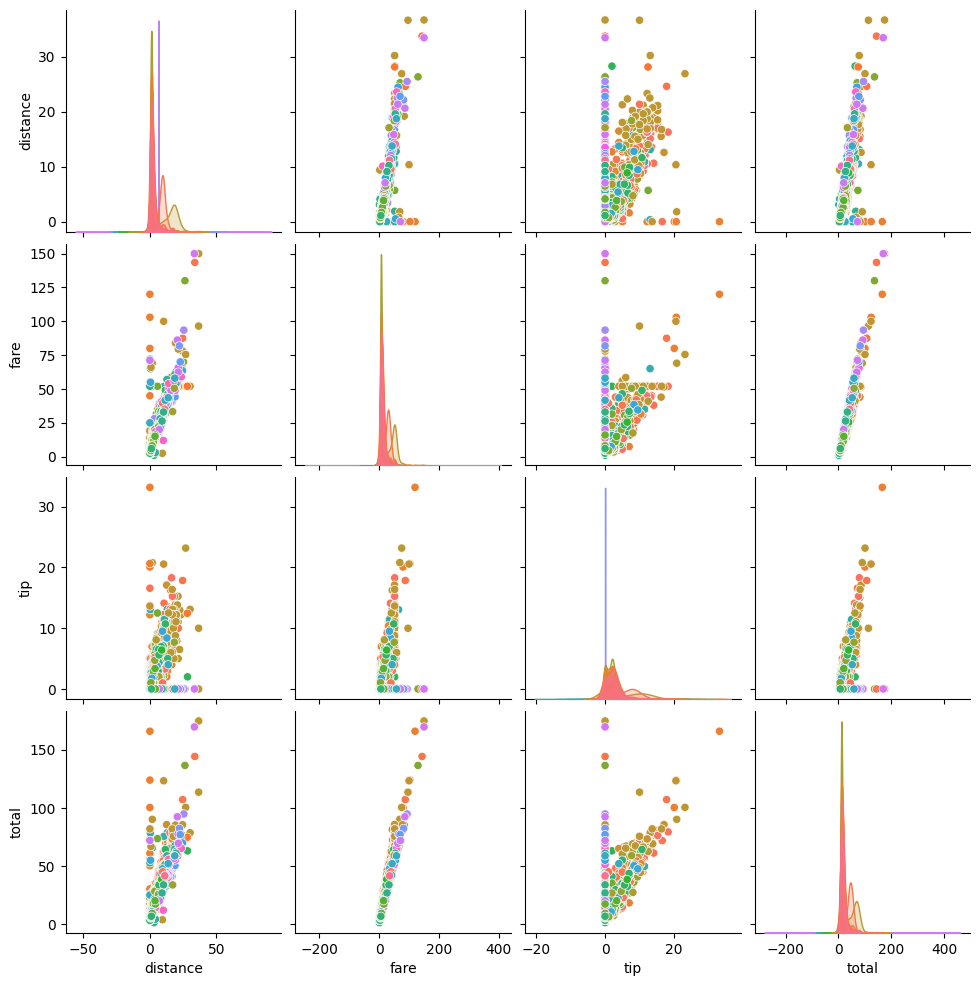

In [ ]:
# Pair Plot
# Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total.
# Color the data points according to the pickup_zone column. to compare how different zones
# affect these variables.
plt.figure(figsize = (9,9))
num_pair=df[['distance', 'fare', 'tip', 'total','pickup_zone']]
g = sns.pairplot(num_pair,hue='pickup_zone')
g._legend.remove()
plt.show()

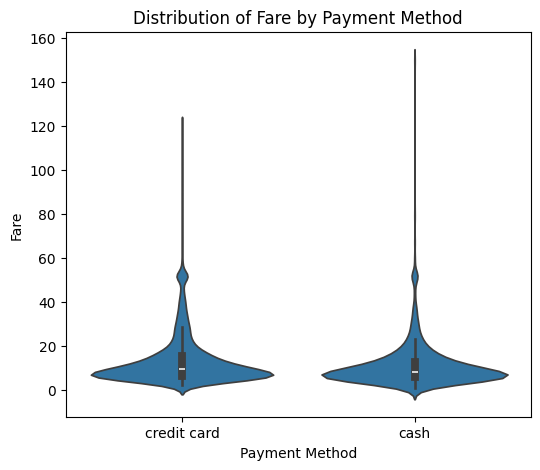

In [ ]:
# Violin Plot
# Plot a violin plot to show the distribution of fare for each payment method. Use the payment
# method as the categorical axis and fare as the numeric axis to visualize its distribution.
plt.figure(figsize=(6,5))
sns.violinplot(x="payment", y ="fare", data = df)
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Distribution of Fare by Payment Method")
plt.show()